# Q2.1 - Part 1: Classical Model baselines - TF-IDF + LR and SVM

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print("Train size: ", len(train_df))
print("Val size: ", len(val_df))
print("Test size: ", len(test_df))
print(train_df.head(3))

Train size:  3747
Val size:  313
Test size:  2183
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  


In [3]:
# Turning the floats into int 

train_df['Sentiment'] = train_df['Sentiment'].astype(int)
train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)

val_df['Sentiment'] = val_df['Sentiment'].astype(int)
val_df['Sarcasm']   = val_df['Sarcasm'].astype(int)

test_df['Sentiment'] = test_df['Sentiment'].astype(int)
test_df['Sarcasm']   = test_df['Sarcasm'].astype(int)

print(train_df.dtypes)
print(train_df.head(3))

text           str
variety        str
source         str
Sentiment    int64
Sarcasm      int64
dtype: object
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   

   Sentiment  Sarcasm  
0          0        0  
1          0        1  
2          1        0  


In [4]:
# Training data per variety

train_uk = train_df[train_df['variety'] == 'en-UK']
train_au = train_df[train_df['variety'] == 'en-AU']
train_in = train_df[train_df['variety'] == 'en-IN']

# Test data per variety

test_uk = test_df[test_df['variety'] == 'en-UK']
test_au = test_df[test_df['variety'] == 'en-AU']
test_in = test_df[test_df['variety'] == 'en-IN']

print("Train sizes:")
print("en-UK: ", len(train_uk))
print("en-AU: ", len(train_au))
print("en-IN: ", len(train_in))

print("\nTest sizes:")
print("en-UK: ", len(test_uk))
print("en-AU: ", len(test_au))
print("en-IN: ", len(test_in))

Train sizes:
en-UK:  1203
en-AU:  1145
en-IN:  1399

Test sizes:
en-UK:  700
en-AU:  667
en-IN:  816


In [5]:
# All varieties combined - for Q2.1

X_train = train_df['text'].tolist()
X_val = val_df['text'].tolist()
X_test = test_df['text'].tolist()

# Sarcasm labels

y_train_sarcasm = train_df['Sarcasm'].tolist()
y_val_sarcasm = val_df['Sarcasm'].tolist()
y_test_sarcasm = test_df['Sarcasm'].tolist()

# Sentiment labels

y_train_sentiment = train_df['Sentiment'].tolist()
y_val_sentiment   = val_df['Sentiment'].tolist()
y_test_sentiment  = test_df['Sentiment'].tolist()

print("Sarcasm class distribution in training set:")
print("Not Sarcastic (0): ", y_train_sarcasm.count(0))
print("Sarcastic (1): ", y_train_sarcasm.count(1))

print("\nSentiment class distribution in training set:")
print("Negative (0): ", y_train_sentiment.count(0))
print("Positive (1): ", y_train_sentiment.count(1))

Sarcasm class distribution in training set:
Not Sarcastic (0):  3223
Sarcastic (1):  524

Sentiment class distribution in training set:
Negative (0):  1907
Positive (1):  1840


In [6]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2)) # Taken single and double words as features

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shape:")
print("Train: ", X_train_tfidf.shape)
print("Val: ", X_val_tfidf.shape)
print("Test: ", X_test_tfidf.shape)

TF-IDF matrix shape:
Train:  (3747, 10000)
Val:  (313, 10000)
Test:  (2183, 10000)


In [7]:
# Logistic regression on Sarcasm

lr_sarcasm = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_sarcasm.fit(X_train_tfidf, y_train_sarcasm)

lr_sarcasm_preds = lr_sarcasm.predict(X_test_tfidf)

print(f"{'-'*10} Logistic Regression - Sarcasm {'-'*10}")
print(classification_report(y_test_sarcasm, lr_sarcasm_preds, target_names=['Not Sarcastic', 'Sarcastic']))

---------- Logistic Regression - Sarcasm ----------
               precision    recall  f1-score   support

Not Sarcastic       0.92      0.79      0.85      1878
    Sarcastic       0.31      0.59      0.41       305

     accuracy                           0.76      2183
    macro avg       0.62      0.69      0.63      2183
 weighted avg       0.84      0.76      0.79      2183



In [8]:
# Logistic Regression on Sentiment

lr_sentiment = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_sentiment.fit(X_train_tfidf, y_train_sentiment)

lr_sentiment_preds = lr_sentiment.predict(X_test_tfidf)

print(f"{'-'*10} Logistic Regression - Sentiment {'-'*10}")
print(classification_report(y_test_sentiment, lr_sentiment_preds, target_names=['Negative', 'Positive']))

---------- Logistic Regression - Sentiment ----------
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84      1117
    Positive       0.84      0.80      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



In [9]:
# SVM on Sarcasm

svm_sarcasm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_sarcasm.fit(X_train_tfidf, y_train_sarcasm)

svm_sarcasm_preds = svm_sarcasm.predict(X_test_tfidf)

print(f"{'-'*10} SVM - Sarcasm {'-'*10}")
print(classification_report(y_test_sarcasm, svm_sarcasm_preds, target_names=['Not Sarcastic', 'Sarcastic']))

---------- SVM - Sarcasm ----------
               precision    recall  f1-score   support

Not Sarcastic       0.89      0.89      0.89      1878
    Sarcastic       0.32      0.32      0.32       305

     accuracy                           0.81      2183
    macro avg       0.60      0.60      0.60      2183
 weighted avg       0.81      0.81      0.81      2183



In [10]:
svm_sentiment = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_sentiment.fit(X_train_tfidf, y_train_sentiment)

svm_sentiment_preds = svm_sentiment.predict(X_test_tfidf)

print(f"{'-'*10} SVM - Sentiment {'-'*10}")
print(classification_report(y_test_sentiment, svm_sentiment_preds, target_names=['Negative', 'Positive']))

---------- SVM - Sentiment ----------
              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84      1117
    Positive       0.84      0.82      0.83      1066

    accuracy                           0.84      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.84      0.84      0.84      2183



In [11]:
# Run 2 - different random seed
lr_sarcasm_run2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=0)
lr_sarcasm_run2.fit(X_train_tfidf, y_train_sarcasm)
lr_sarcasm_preds_run2 = lr_sarcasm_run2.predict(X_test_tfidf)

svm_sarcasm_run2 = LinearSVC(class_weight='balanced', random_state=0, max_iter=2000)
svm_sarcasm_run2.fit(X_train_tfidf, y_train_sarcasm)
svm_sarcasm_preds_run2 = svm_sarcasm_run2.predict(X_test_tfidf)

from sklearn.metrics import f1_score

lr_f1_run1  = f1_score(y_test_sarcasm, lr_sarcasm_preds, average='macro')
lr_f1_run2  = f1_score(y_test_sarcasm, lr_sarcasm_preds_run2, average='macro')
svm_f1_run1 = f1_score(y_test_sarcasm, svm_sarcasm_preds, average='macro')
svm_f1_run2 = f1_score(y_test_sarcasm, svm_sarcasm_preds_run2, average='macro')

print(f"{'-'*10} Sarcasm - 2 Run Comparison {'-'*10}")
print(f"LR  - Run 1: {lr_f1_run1:.4f} | Run 2: {lr_f1_run2:.4f}")
print(f"SVM - Run 1: {svm_f1_run1:.4f} | Run 2: {svm_f1_run2:.4f}")

---------- Sarcasm - 2 Run Comparison ----------
LR  - Run 1: 0.6293 | Run 2: 0.6293
SVM - Run 1: 0.6028 | Run 2: 0.6028


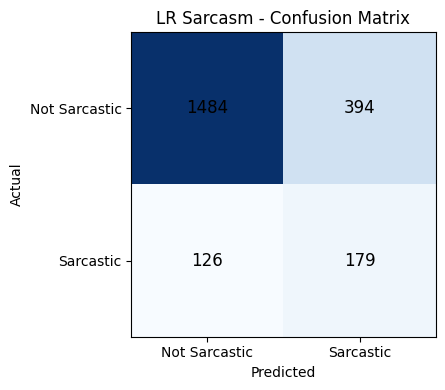

[[1484  394]
 [ 126  179]]


In [12]:
cm = confusion_matrix(y_test_sarcasm, lr_sarcasm_preds)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Sarcastic', 'Sarcastic'])
ax.set_yticklabels(['Not Sarcastic', 'Sarcastic'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('LR Sarcasm - Confusion Matrix')
plt.tight_layout()
plt.savefig('figures/lr_sarcasm_cm.png', dpi=150)
plt.show()
print(cm)

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'LR - Sarcasm'   : (y_test_sarcasm,   lr_sarcasm_preds),
    'SVM - Sarcasm'  : (y_test_sarcasm,   svm_sarcasm_preds),
    'LR - Sentiment' : (y_test_sentiment, lr_sentiment_preds),
    'SVM - Sentiment': (y_test_sentiment, svm_sentiment_preds),
}

for name, (y_true, y_pred) in models.items():
    p  = precision_score(y_true, y_pred, average='macro')
    r  = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(name)
    print("  Precision: ", round(p, 4))
    print("  Recall: ", round(r, 4))
    print("  Macro F1: ", round(f1, 4))
    print()

LR - Sarcasm
  Precision:  0.6171
  Recall:  0.6885
  Macro F1:  0.6293

SVM - Sarcasm
  Precision:  0.6025
  Recall:  0.6031
  Macro F1:  0.6028

LR - Sentiment
  Precision:  0.8306
  Recall:  0.8289
  Macro F1:  0.8292

SVM - Sentiment
  Precision:  0.8354
  Recall:  0.8347
  Macro F1:  0.8349



# Q2.1 - Part 2: Fine-tuned Transformer (RoBERTa)

In [14]:
pip install transformers torch accelerate


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Testing it on one sentence to see everything is fine
sample = "This is absolutely brilliant, thanks for nothing."
tokens = tokenizer(sample, truncation=True, padding=True, return_tensors='pt')

print("Input IDs:", tokens['input_ids'])
print("Shape:", tokens['input_ids'].shape)

Input IDs: tensor([[   0,  713,   16, 3668, 6967,    6, 2446,   13, 1085,    4,    2]])
Shape: torch.Size([1, 11])


In [18]:
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts      # list of all sentences
        self.labels = labels    # list of all labels (0 or 1)
        self.tokenizer = tokenizer  # RoBERTa tokeniser
        self.max_len = max_len  # max number of tokens per sentence
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(), # Removes extra dimension for the DataLoader [1, 128] -> [128]
            'attention_mask': encoding['attention_mask'].squeeze(), # Real token without padding
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [19]:
# DataLoaders

train_dataset = SarcasmDataset(X_train, y_train_sarcasm, tokenizer)
val_dataset = SarcasmDataset(X_val, y_val_sarcasm, tokenizer)
test_dataset = SarcasmDataset(X_test, y_test_sarcasm, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Training batches: ", len(train_loader))
print("Validation batches: ", len(val_loader))
print("Test batches: ", len(test_loader))

Training batches:  235
Validation batches:  20
Test batches:  137


In [20]:
# Load RoBERTA model 

model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model = model.to(device)

print("Model loaded!")
print("Number of parameters: ", sum(p.numel() for p in model.parameters()))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
Number of parameters:  124647170


In [21]:
# Training function 

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    return total_loss/len(loader)


In [22]:
def evaluate(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [23]:
import os
from sklearn.metrics import f1_score

optimizer = AdamW(model.parameters(), lr=2e-5)

best_val_f1 = 0
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_labels, val_preds = evaluate(model, val_loader)
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Macro F1: {val_f1:.4f}")
    print("*****")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        os.makedirs('models/roberta_sarcasm', exist_ok=True)
        model.save_pretrained('models/roberta_sarcasm')
        tokenizer.save_pretrained('models/roberta_sarcasm')
        print(f"  Best model saved at epoch {epoch+1}")
    print()

print(f"Best Val Macro F1: {best_val_f1:.4f}")

Epoch 1/5
  Train Loss: 0.3452
  Val Macro F1: 0.6233
*****


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved at epoch 1

Epoch 2/5
  Train Loss: 0.2874
  Val Macro F1: 0.4622
*****

Epoch 3/5
  Train Loss: 0.2187
  Val Macro F1: 0.6239
*****


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved at epoch 3

Epoch 4/5
  Train Loss: 0.1420
  Val Macro F1: 0.6563
*****


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved at epoch 4

Epoch 5/5
  Train Loss: 0.0727
  Val Macro F1: 0.7493
*****


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved at epoch 5

Best Val Macro F1: 0.7493


In [24]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

best_model = AutoModelForSequenceClassification.from_pretrained('models/roberta_sarcasm')
best_model = best_model.to(device)

test_labels, test_preds = evaluate(best_model, test_loader)

print(f"{'-'*10} RoBERTA - Sarcasm - Test Set {'-'*10}")
print(classification_report(test_labels, test_preds, target_names=['Not Sarcastic', 'Sarcastic']))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

---------- RoBERTA - Sarcasm - Test Set ----------
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.92      0.92      1878
    Sarcastic       0.50      0.47      0.48       305

     accuracy                           0.86      2183
    macro avg       0.71      0.69      0.70      2183
 weighted avg       0.86      0.86      0.86      2183



In [25]:
# Run 2 - reinitialise model with different seed
torch.manual_seed(0)
model_run2 = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model_run2 = model_run2.to(device)
optimizer_run2 = AdamW(model_run2.parameters(), lr=2e-5)

best_val_f1_run2 = 0
for epoch in range(5):
    train_loss = train_epoch(model_run2, train_loader, optimizer_run2)
    val_labels, val_preds = evaluate(model_run2, val_loader)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    print(f"Epoch {epoch+1}/5 - Loss: {train_loss:.4f} - Val F1: {val_f1:.4f}")
    if val_f1 > best_val_f1_run2:
        best_val_f1_run2 = val_f1

print(f"Run 1 Best Val F1: {best_val_f1:.4f}")
print(f"Run 2 Best Val F1: {best_val_f1_run2:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 - Loss: 0.3467 - Val F1: 0.4622
Epoch 2/5 - Loss: 0.3113 - Val F1: 0.4622
Epoch 3/5 - Loss: 0.2685 - Val F1: 0.6200
Epoch 4/5 - Loss: 0.2227 - Val F1: 0.6632
Epoch 5/5 - Loss: 0.1527 - Val F1: 0.6745
Run 1 Best Val F1: 0.7493
Run 2 Best Val F1: 0.6745
